## Initial Dictionaries

The idea of learning dictionary functions that we explore relies on deforming an original dictionary. Therefore, it is first natural to implement different initial bases to deform. In this notebook, we will cover multiple examples of basis functions on different domains $\Omega$.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Hat (Tent) Basis on a Square

Here we take $\Omega = [0,1]^2$ and use the standard **hat (P1 Lagrange) basis**: for each grid node $x_i \in \Omega$, we define a continuous, piecewise-linear function $e_i$ that satisfies $e_i(x_i)=1$ and $e_i(x_j)=0$ for all other nodes $x_j$. Each $e_i$ has compact (local) support—nonzero only on the elements that touch $x_i$—which is why these functions are widely used as shape functions in the finite element method.

Run the code below to visualize these basis functions on a coarse $3\times 3$ grid of nodes.

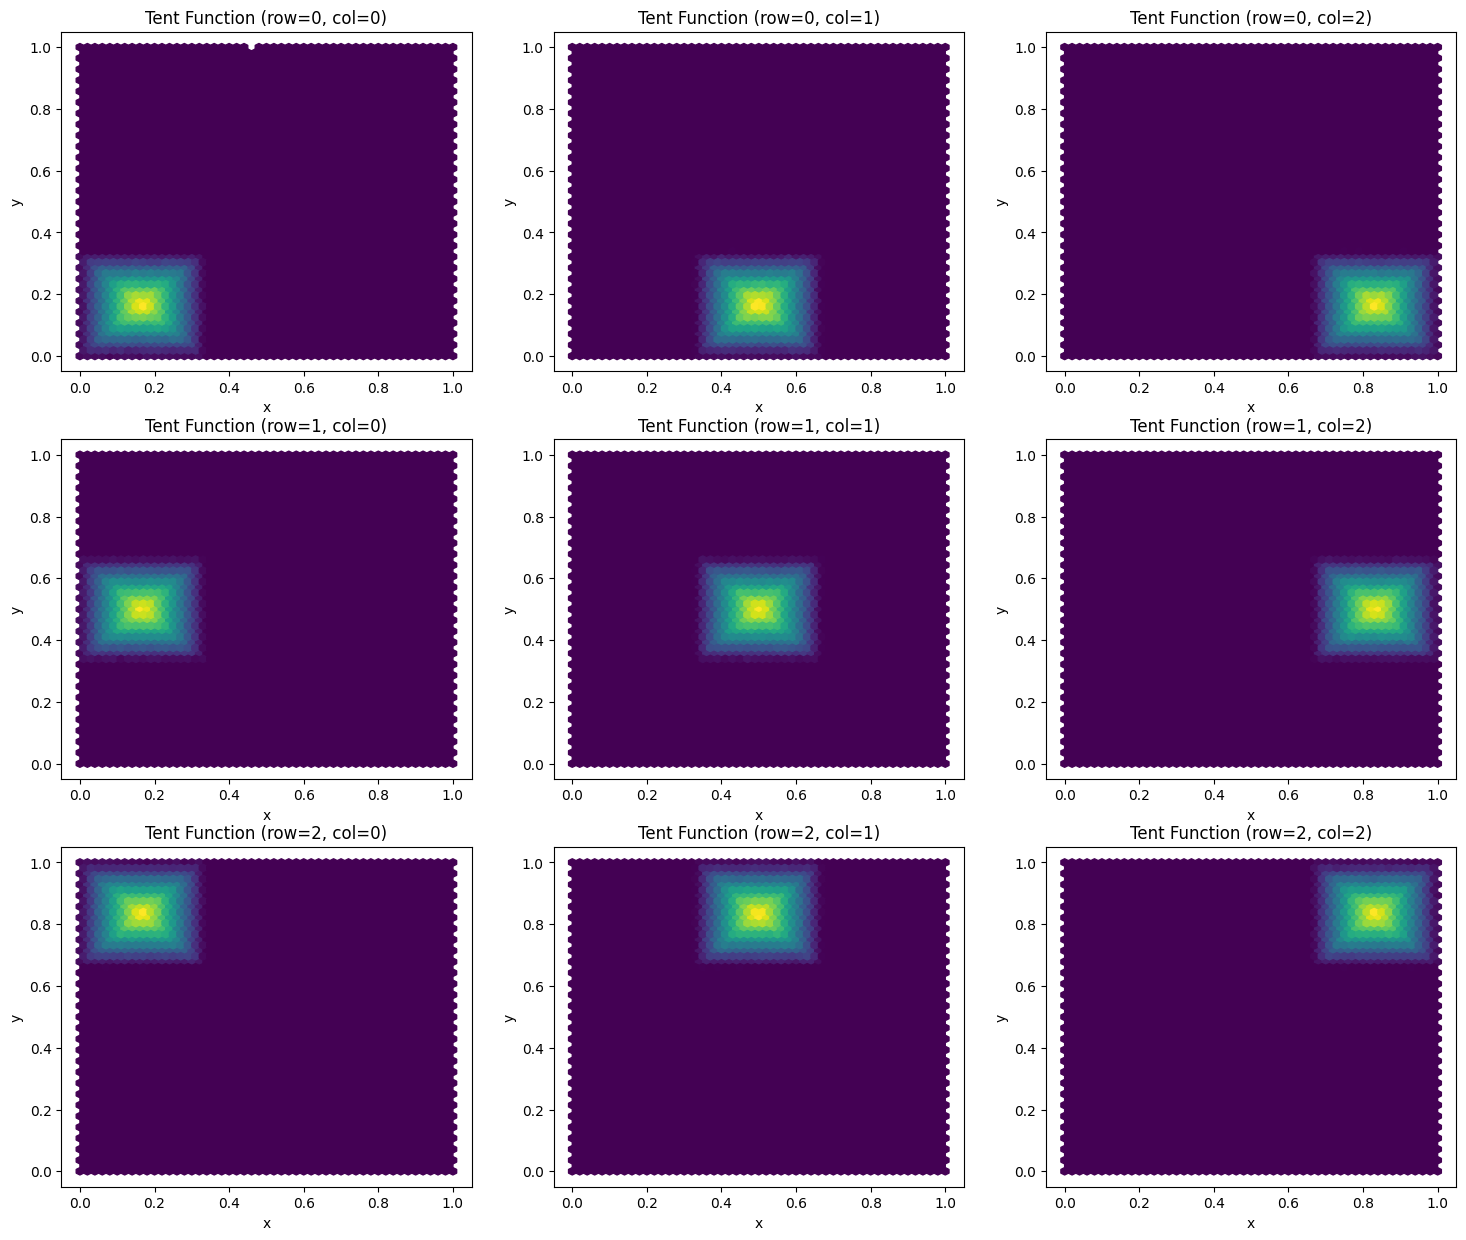

In [2]:
%autoreload 2
from infidictionary.dictionaries import TentDictionary

tent_basis = TentDictionary(total_rows=3, total_cols=3)

# visualize bumps
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
indices = [
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8],
]
N = 5000_0
all_vals = []
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        xy = tent_basis.sample_from_domain(N).cpu()
        idx = indices[row][col]
        vals = tent_basis.get_atom(xy.to(device), idx).cpu()
        all_vals.append(vals.numpy())
        ax.hexbin(xy[:,0], xy[:,1], C=vals, gridsize=50, cmap='viridis') 
        ax.set_title(f'Tent Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()
    

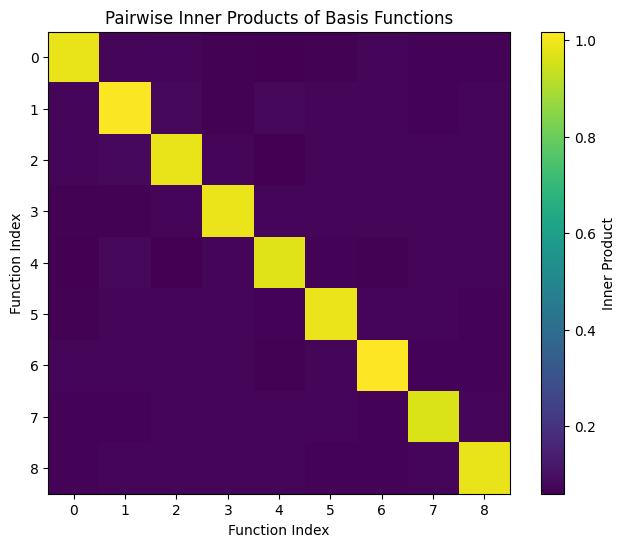

In [3]:
def inner_product_heatmap(all_vals: list):
    # compute pairwise inner products
    inner_products = np.zeros((9, 9))
    for i in range(9):
        for j in range(9):
            vi = all_vals[i]
            vj = all_vals[j]
            inner_products[i, j] = np.mean(vi * vj)
    # heatmap of inner products
    plt.figure(figsize=(8, 6))
    plt.imshow(inner_products)
    plt.colorbar(label='Inner Product')
    plt.title('Pairwise Inner Products of Basis Functions')
    plt.xlabel('Function Index')
    plt.ylabel('Function Index')
    plt.show()
    
inner_product_heatmap(all_vals)

## 2D Fourier Basis

Next, we consider the 2D Fourier basis on $\Omega = [0, 1]^2$. Each basis is indexed by two elements $i, j \in \mathbb{N} \cup \{0\}$ and is defined as below:

$$e_i^{\sin}(t) = \begin{cases}
\sqrt{2} \sin(2 \pi i t) & \text{if } i > 0\\
1 & \text{if } i = 0
\end{cases}, \qquad e_i^{cos}(t) = \begin{cases}
\sqrt{2} \cos(2 \pi i t) & \text{if } i > 0\\
1 & \text{if } i = 0
\end{cases}$$

$$e^0_{ij}(x, y) = e_i^{\sin}(x) e_j^{\sin}(y), \quad e^1_{ij}(x, y) = e_i^{\sin}(x) e_j^{\cos}(y)$$
$$e^2_{ij}(x, y) = e_i^{\cos}(x) e_j^{\sin}(y), \quad e^3_{ij}(x, y) = e_i^{\cos}(x) e_j^{\cos}(y)$$

One can check using Fubini and completeness of the 1D Fourier basis that the above is also a complete basis of the functions supported on $[0, 1]^2$ when one considers all of the indices $i, j$.

Run the following to visualize some of the basis functions, the callable function not only takes $i$ and $j$, but also takes a `kind` argument that specifies what kind of cosine and sine combination it is a multiple of:

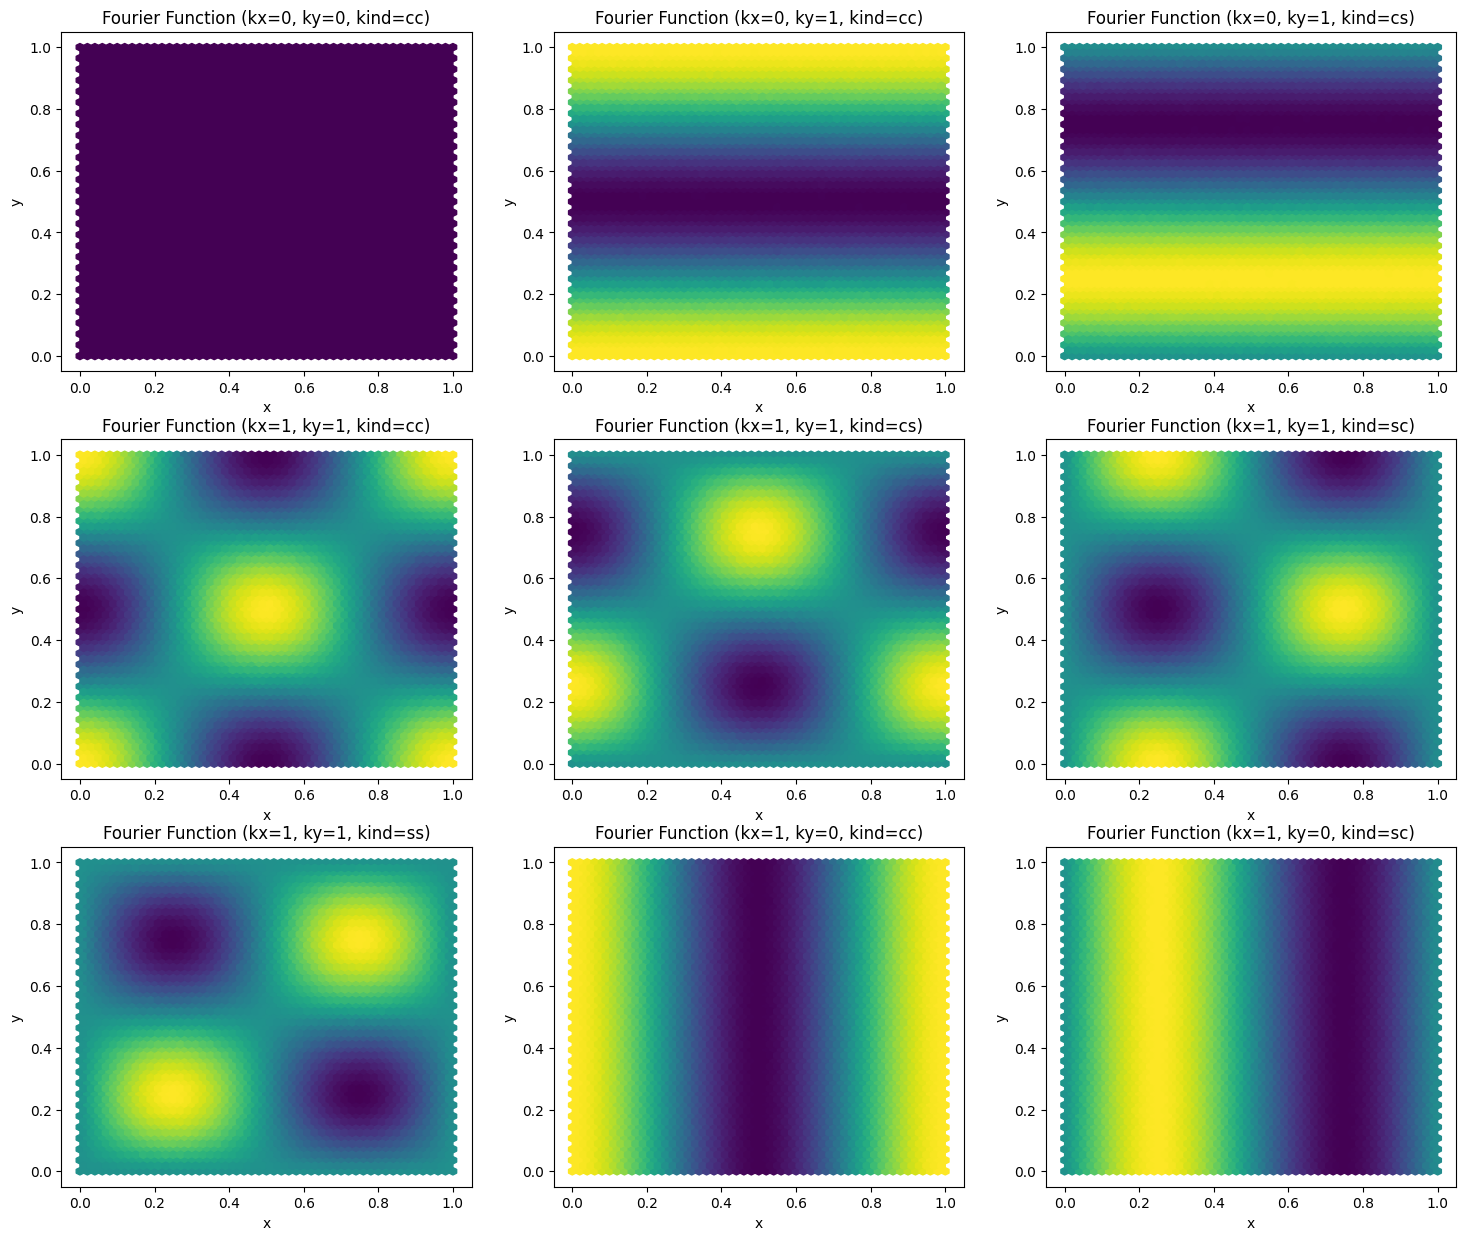

In [7]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary

fourier_basis = FourierDictionary()
indices = [
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8],
]

fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
N = 5000_0
all_vals = []
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        xy = fourier_basis.sample_from_domain(N).cpu()
        idx = indices[row][col]
        vals = fourier_basis.get_atom(xy.to(device), idx).cpu()
        all_vals.append(vals.numpy())
        ax.hexbin(xy[:,0], xy[:,1], C=vals, gridsize=50, cmap='viridis') 
        kx, ky, kind = fourier_basis.idx_to_params(idx)
        ax.set_title(f'Fourier Function (kx={kx}, ky={ky}, kind={kind})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

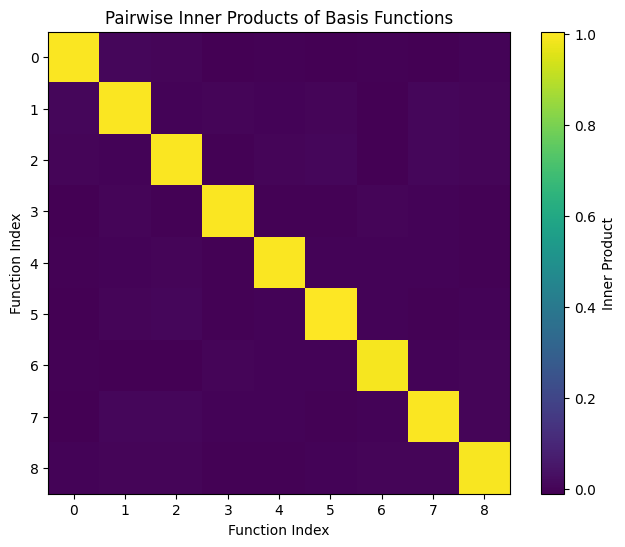

In [8]:
inner_product_heatmap(all_vals)

## Radial Bases

The uniform measure $\mu$ on $\Omega$ is obtained via the following change of variables:

$$y = \sqrt{r} \sin (2\pi \theta), \qquad x = \sqrt{r} \cos(2\pi \theta), \qquad r, \theta \sim \text{Unif}[0, 1]$$

One can check that through this change of variable, $(x, y)$ is uniform on the unit disk. 

Next, we use the same trick as the 2D Fourier to construct a two-dimensional basis on the disk:

$$e^{0}_{ij}(x, y) = e_i^{\sin}(x^2 + y^2) \cdot e_j^{\sin}(\tfrac{\tan^{-1}(\tfrac{y}{x})}{2\pi}), \qquad e^{1}_{ij}(x, y) = e_i^{\sin}(x^2 + y^2) \cdot e_j^{\cos}(\tfrac{\tan^{-1}(\tfrac{y}{x})}{2\pi}),$$
$$e^{2}_{ij}(x, y) = e_i^{\cos}(x^2 + y^2) \cdot e_j^{\sin}(\tfrac{\tan^{-1}(\tfrac{y}{x})}{2\pi}), \qquad e^{3}_{ij}(x, y) = e_i^{\cos}(x^2 + y^2) \cdot e_j^{\cos}(\tfrac{\tan^{-1}(\tfrac{y}{x})}{2\pi}).$$

We can check orthonormality mathematically using the two change of variables $r = x^2 + y^2, \theta = \tfrac{\tan^{-1}(y/x)}{2\pi}$ and Fubini; as an example, consider $e^0_{ij}$ and $e^{0}_{i'j'}$:

\begin{align}
\langle e^0_{ij}, e^{0}_{i'j'} \rangle & = \int_{\Omega} e^0_{ij}(x, y) e^{0}_{i'j'}(x, y) \mu(dx, dy)\nonumber\\
& = \int_0^1 \int_0^1 e_i^{\sin}(r) e_j^{\sin}(\theta) e_{i'}^{\sin}(r) e_{j'}^{\sin}(\theta) dr d\theta \quad \text{Change of Variables}\nonumber\\
& = \int_0^1 e_i^{\sin}(r) e_{i'}^{\sin}(r) dr \cdot \int_0^1 e_j^{\sin}(\theta) e_{j'}^{\sin}(\theta) d\theta \quad \text{Fubini} \nonumber\\
& = \delta_{ii'} \cdot \delta_{jj'}\nonumber.
\end{align}

Run the following piece of code to visualize some of the basis elements:


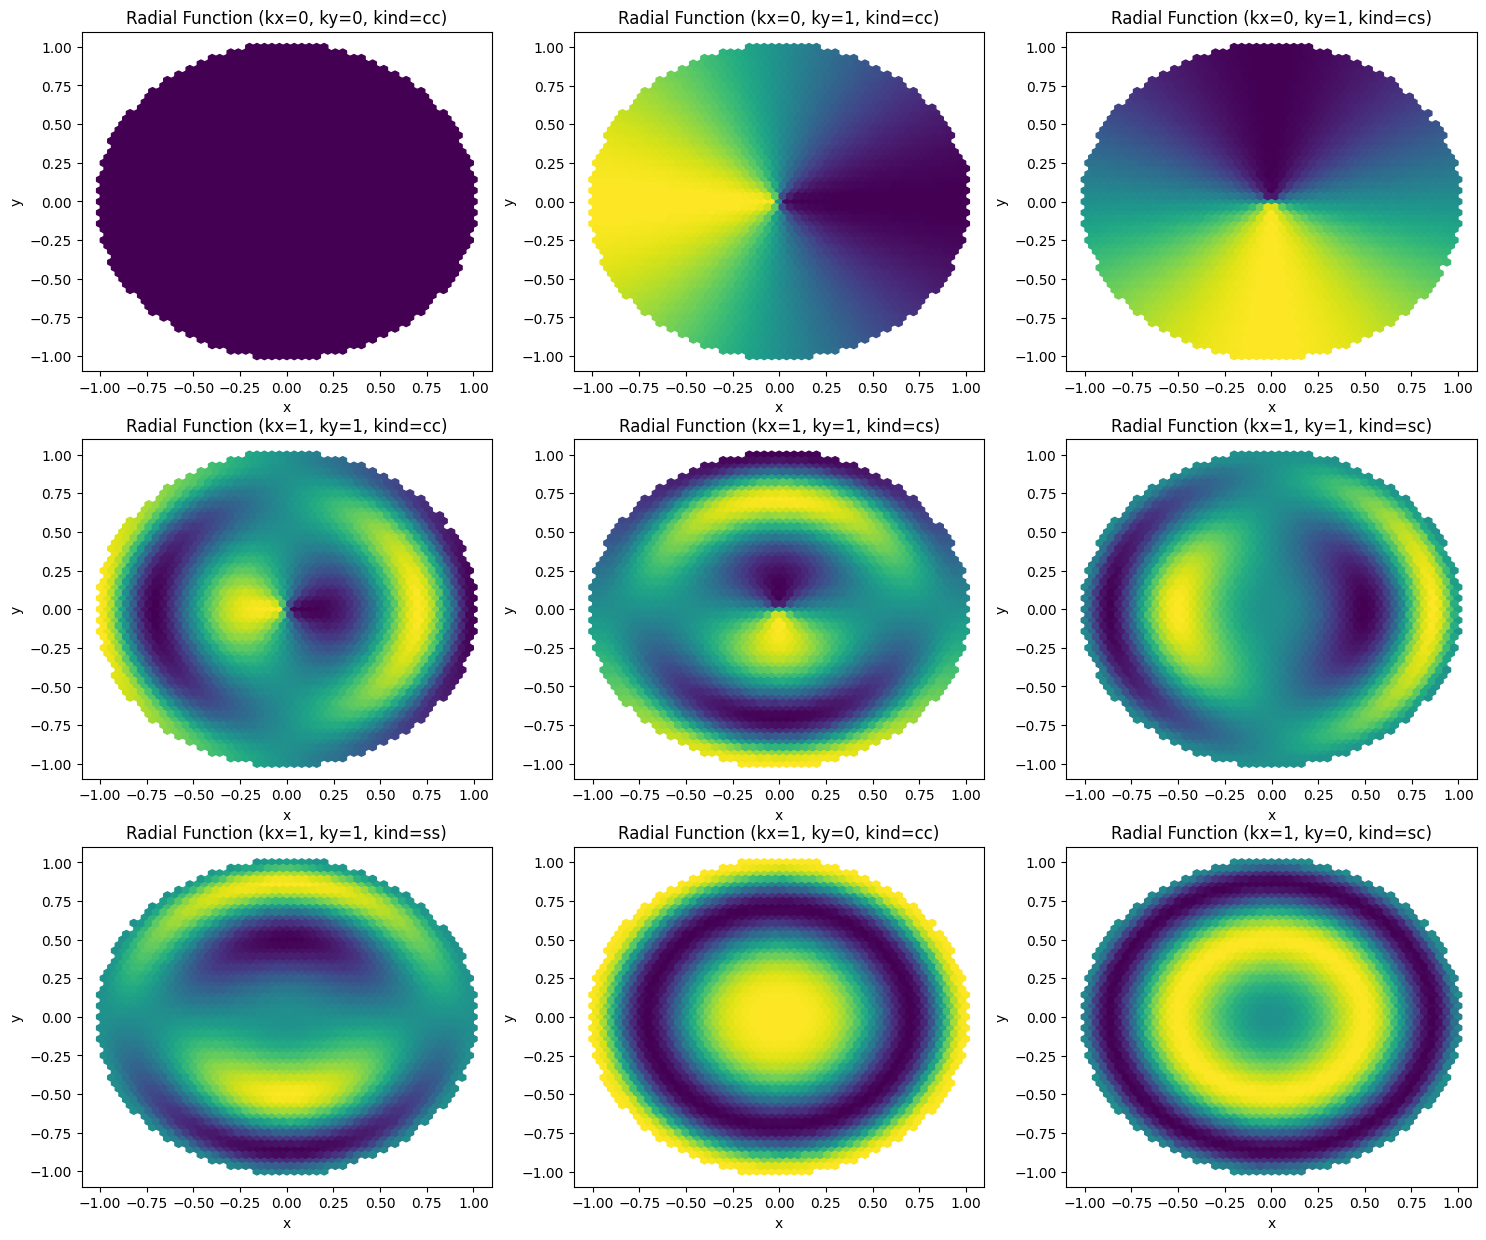

In [12]:
%autoreload 2
from infidictionary.dictionaries import RadialFourierDictionary

radial_fourier = RadialFourierDictionary()
indices = [
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8],
]
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
all_vals = []
N = 5000_0
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        xy = radial_fourier.sample_from_domain(N)
        idx = indices[row][col]
        vals = radial_fourier.get_atom(xy.to(device), idx)
        all_vals.append(vals.cpu().detach().numpy())
        ax.hexbin(xy[:,0].cpu().detach(), xy[:,1].cpu().detach(), C=vals.cpu().detach(), gridsize=50, cmap='viridis') 
        kx, ky, kind = radial_fourier.idx_to_params(idx)
        ax.set_title(f'Radial Function (kx={kx}, ky={ky}, kind={kind})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()
    

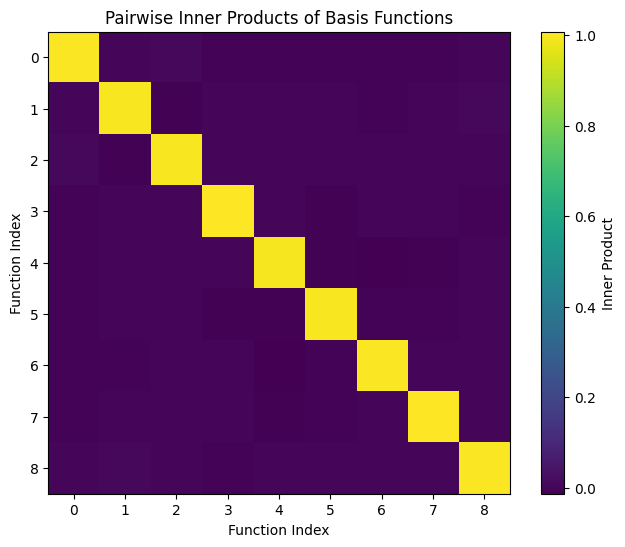

In [13]:
inner_product_heatmap(all_vals)

A similar transform can be done for the tent basis:

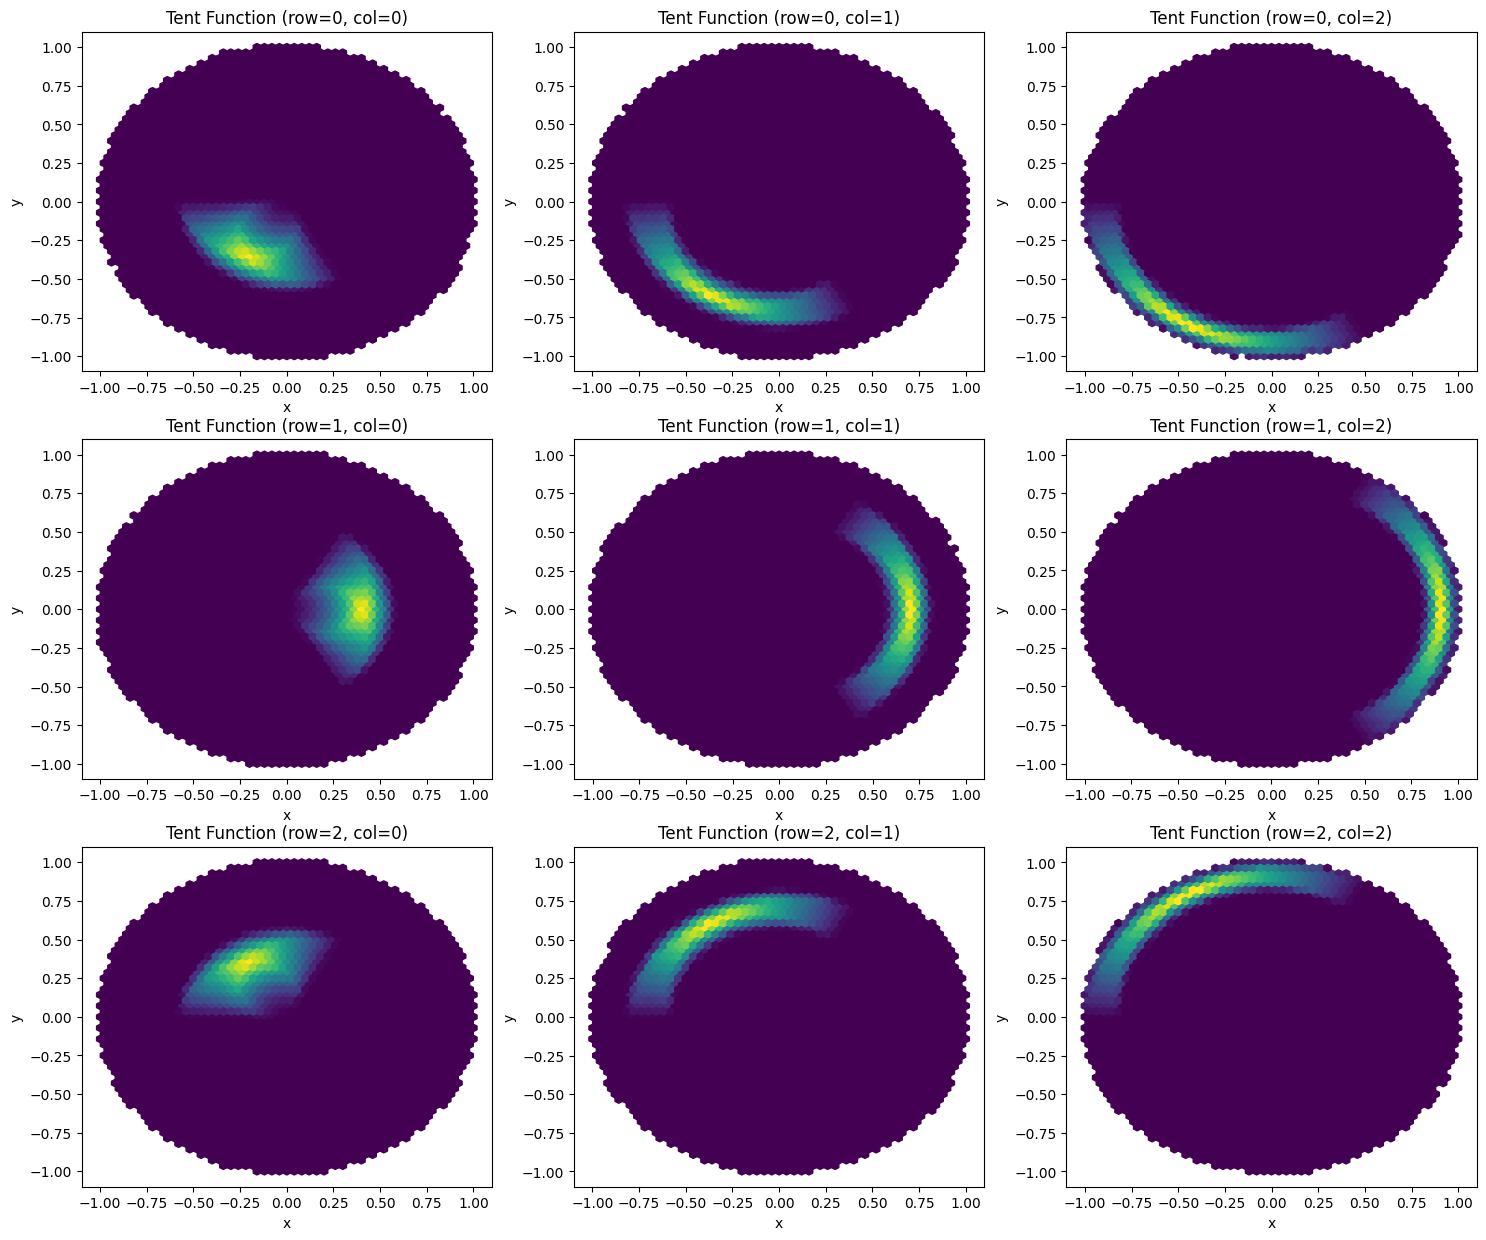

In [17]:
%autoreload 2
from infidictionary.dictionaries import RadialTentDictionary

tent_basis = RadialTentDictionary(total_rows=3, total_cols=3)
# visualize bumps
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
N = 5000_0
all_vals = []
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        xy = tent_basis.sample_from_domain(N).cpu()
        vals = tent_basis.get_atom(xy, row * 3 + col).cpu()
        all_vals.append(vals.numpy())
        ax.hexbin(xy[:,0], xy[:,1], C=vals, gridsize=50, cmap='viridis') 
        ax.set_title(f'Tent Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()
    

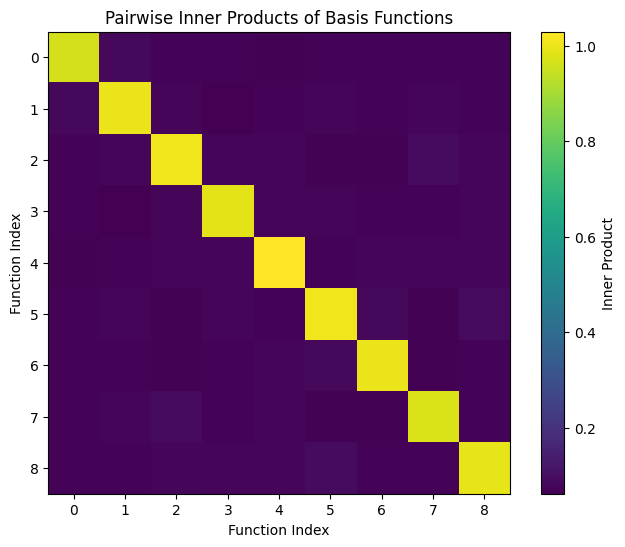

In [18]:
inner_product_heatmap(all_vals)